# mlflow db analysis 

Loads runs from mlflow into a df for visualization, curation, and analysis.

In [1]:
from pathlib import Path
import mlflow
import pandas as pd
import plotly.express as px

In [2]:
output_dir = Path("mlflow_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

In [3]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

In [4]:
experiment = mlflow.get_experiment_by_name("conservision")
if experiment:
    experiment_id = experiment.experiment_id
    # Load all runs from the experiment into a pandas DataFrame
    runs_df = mlflow.search_runs(experiment_ids=[experiment_id])
else:
    print("Experiment not found.")

2026/03/12 10:48:03 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/12 10:48:03 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/12 10:48:03 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/12 10:48:03 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/12 10:48:03 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/12 10:48:03 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/12 10:48:03 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/12 10:48:03 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [5]:
runs_df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_acc,metrics.val_f1_macro,metrics.f1_blank,metrics.val_acc,...,params.batch_size,params.class_weights.blank,params.class_weighting,params.num_workers,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.git.commit,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.runColor
0,61b2042dd74447c2abbaf573951d0f4d,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/61b2...,2026-03-12 08:05:18.802000+00:00,2026-03-12 09:19:23.982000+00:00,0.941694,0.6064,0.4154,0.641331,...,8,1.0179,inverse_frequency,4,vit_so150_fold4,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
1,79bea0cfa1134725a94eacc064f15bdd,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/79be...,2026-03-12 06:38:46.498000+00:00,2026-03-12 08:04:39.794000+00:00,0.949134,0.7318,0.4868,0.711310,...,8,1.0293,inverse_frequency,4,vit_so150_fold3,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
2,3e64b69e1ad44e979996fee939a04ac3,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/3e64...,2026-03-12 05:18:02.588000+00:00,2026-03-12 06:38:07.409000+00:00,0.947376,0.5629,0.5663,0.588856,...,8,1.0315,inverse_frequency,4,vit_so150_fold2,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
3,9a24a29413d34d5c9dd4bb5fe71fbe17,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/9a24...,2026-03-12 04:03:05.205000+00:00,2026-03-12 05:17:23.268000+00:00,0.944738,0.5410,0.6117,0.534613,...,8,1.0937,inverse_frequency,4,vit_so150_fold1,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
4,7fe539e966624303842728375212236b,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/7fe5...,2026-03-12 02:36:20.507000+00:00,2026-03-12 04:02:25.586000+00:00,0.949472,0.6935,0.6336,0.720584,...,8,0.9678,inverse_frequency,4,vit_so150_fold0,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None


In [6]:
runs_df.shape

(137, 65)

In [7]:
runs_df.to_csv(output_dir / 'all_runs.csv')

In [8]:
runs_df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_acc,metrics.val_f1_macro,metrics.f1_blank,metrics.val_acc,...,params.batch_size,params.class_weights.blank,params.class_weighting,params.num_workers,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.git.commit,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.runColor
0,61b2042dd74447c2abbaf573951d0f4d,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/61b2...,2026-03-12 08:05:18.802000+00:00,2026-03-12 09:19:23.982000+00:00,0.941694,0.6064,0.4154,0.641331,...,8,1.0179,inverse_frequency,4,vit_so150_fold4,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
1,79bea0cfa1134725a94eacc064f15bdd,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/79be...,2026-03-12 06:38:46.498000+00:00,2026-03-12 08:04:39.794000+00:00,0.949134,0.7318,0.4868,0.711310,...,8,1.0293,inverse_frequency,4,vit_so150_fold3,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
2,3e64b69e1ad44e979996fee939a04ac3,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/3e64...,2026-03-12 05:18:02.588000+00:00,2026-03-12 06:38:07.409000+00:00,0.947376,0.5629,0.5663,0.588856,...,8,1.0315,inverse_frequency,4,vit_so150_fold2,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
3,9a24a29413d34d5c9dd4bb5fe71fbe17,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/9a24...,2026-03-12 04:03:05.205000+00:00,2026-03-12 05:17:23.268000+00:00,0.944738,0.5410,0.6117,0.534613,...,8,1.0937,inverse_frequency,4,vit_so150_fold1,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
4,7fe539e966624303842728375212236b,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/7fe5...,2026-03-12 02:36:20.507000+00:00,2026-03-12 04:02:25.586000+00:00,0.949472,0.6935,0.6336,0.720584,...,8,0.9678,inverse_frequency,4,vit_so150_fold0,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None


In [9]:
runs_df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.train_acc', 'metrics.val_f1_macro',
       'metrics.f1_blank', 'metrics.val_acc', 'metrics.best_val_loss',
       'metrics.best_val_acc', 'metrics.f1_monkey_prosimian',
       'metrics.val_loss', 'metrics.f1_civet_genet', 'metrics.val_log_loss',
       'metrics.train_loss', 'metrics.training_time_s', 'metrics.f1_bird',
       'metrics.f1_antelope_duiker', 'metrics.f1_hog', 'metrics.f1_leopard',
       'metrics.lr', 'metrics.f1_rodent', 'params.epochs_unfrozen',
       'params.n_folds', 'params.class_weights.civet_genet',
       'params.epochs_frozen', 'params.num_classes', 'params.augmentation',
       'params.drop_rate', 'params.class_weights.antelope_duiker',
       'params.class_weights.hog', 'params.timm_create_kwargs.img_size',
       'params.imagenet_mean', 'params.lr_backbone', 'params.img_size',
       'params.class_weights.monkey_prosimian', 'params.total_params',
       'para

In [10]:
runs_df['params.backbone'].value_counts()

params.backbone
eva02_base_patch16_clip_224.merged2b                  26
convnext_base.fb_in22k_ft_in1k                        24
vit_base_patch14_dinov2.lvd142m                       23
swinv2_base_window12to16_192to256.ms_in22k_ft_in1k    18
tf_efficientnetv2_s.in21k_ft_in1k                     17
vit_base_patch16_dinov3.lvd1689m                      11
vit_so150m_patch16_reg4_gap_256.sbb_e250_in12k         5
mobilenetv4_conv_small.e2400_r224_in1k                 5
vit_base_patch14_reg4_dinov2.lvd142m                   5
vit_small_patch14_dinov2.lvd142m                       3
Name: count, dtype: int64

In [11]:
runs_df.groupby(['params.backbone'])['metrics.val_f1_macro'].mean()

params.backbone
convnext_base.fb_in22k_ft_in1k                        0.631900
eva02_base_patch16_clip_224.merged2b                  0.634070
mobilenetv4_conv_small.e2400_r224_in1k                0.498720
swinv2_base_window12to16_192to256.ms_in22k_ft_in1k    0.644347
tf_efficientnetv2_s.in21k_ft_in1k                     0.453450
vit_base_patch14_dinov2.lvd142m                       0.641491
vit_base_patch14_reg4_dinov2.lvd142m                  0.692700
vit_base_patch16_dinov3.lvd1689m                      0.672060
vit_small_patch14_dinov2.lvd142m                      0.573933
vit_so150m_patch16_reg4_gap_256.sbb_e250_in12k        0.627120
Name: metrics.val_f1_macro, dtype: float64

In [12]:
runs_df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_acc,metrics.val_f1_macro,metrics.f1_blank,metrics.val_acc,...,params.batch_size,params.class_weights.blank,params.class_weighting,params.num_workers,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.git.commit,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.runColor
0,61b2042dd74447c2abbaf573951d0f4d,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/61b2...,2026-03-12 08:05:18.802000+00:00,2026-03-12 09:19:23.982000+00:00,0.941694,0.6064,0.4154,0.641331,...,8,1.0179,inverse_frequency,4,vit_so150_fold4,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
1,79bea0cfa1134725a94eacc064f15bdd,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/79be...,2026-03-12 06:38:46.498000+00:00,2026-03-12 08:04:39.794000+00:00,0.949134,0.7318,0.4868,0.711310,...,8,1.0293,inverse_frequency,4,vit_so150_fold3,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
2,3e64b69e1ad44e979996fee939a04ac3,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/3e64...,2026-03-12 05:18:02.588000+00:00,2026-03-12 06:38:07.409000+00:00,0.947376,0.5629,0.5663,0.588856,...,8,1.0315,inverse_frequency,4,vit_so150_fold2,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
3,9a24a29413d34d5c9dd4bb5fe71fbe17,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/9a24...,2026-03-12 04:03:05.205000+00:00,2026-03-12 05:17:23.268000+00:00,0.944738,0.5410,0.6117,0.534613,...,8,1.0937,inverse_frequency,4,vit_so150_fold1,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None
4,7fe539e966624303842728375212236b,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/7fe5...,2026-03-12 02:36:20.507000+00:00,2026-03-12 04:02:25.586000+00:00,0.949472,0.6935,0.6336,0.720584,...,8,0.9678,inverse_frequency,4,vit_so150_fold0,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None


In [13]:
runs_df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.train_acc', 'metrics.val_f1_macro',
       'metrics.f1_blank', 'metrics.val_acc', 'metrics.best_val_loss',
       'metrics.best_val_acc', 'metrics.f1_monkey_prosimian',
       'metrics.val_loss', 'metrics.f1_civet_genet', 'metrics.val_log_loss',
       'metrics.train_loss', 'metrics.training_time_s', 'metrics.f1_bird',
       'metrics.f1_antelope_duiker', 'metrics.f1_hog', 'metrics.f1_leopard',
       'metrics.lr', 'metrics.f1_rodent', 'params.epochs_unfrozen',
       'params.n_folds', 'params.class_weights.civet_genet',
       'params.epochs_frozen', 'params.num_classes', 'params.augmentation',
       'params.drop_rate', 'params.class_weights.antelope_duiker',
       'params.class_weights.hog', 'params.timm_create_kwargs.img_size',
       'params.imagenet_mean', 'params.lr_backbone', 'params.img_size',
       'params.class_weights.monkey_prosimian', 'params.total_params',
       'para

In [14]:
runs_df['params.num_classes'].value_counts(dropna=False)

params.num_classes
8    137
Name: count, dtype: int64

In [15]:
ordered = runs_df.sort_values(by='metrics.val_log_loss')

In [16]:
ordered['tags.mlflow.runName'].to_list()

['dinov2_vitb14_reg4_fold3',
 'dinov2_.1_fold3',
 'eva02_.1_b32_fold0',
 'dinov2_vitb14_reg4_fold0',
 'eva02_.1_b32_fold3',
 'swinv2_.1_fold0',
 'swinv2_.1_fold3',
 'dinov2_.1_fold0',
 'convnext_b32_fold0',
 'dino_v3_.1_fold3',
 'convnext_.1',
 'convnext_.1_fold3',
 'dino_05_fold0',
 'dino_v3_.1_fold0',
 'convnext_.1_fold0',
 'dino_v3_.05_fold3',
 'swinv2_.05_fold3',
 'dino_05_fold3',
 'eva02_1_fold3',
 'dinov2_.1_192imgsize_fold3',
 'dinov2_.1',
 'eva02_1_fold0',
 'convnext_b32_fold3',
 'convnext_.05_fold3',
 'evaV2_.05_fold3',
 'dino_v3_.05_fold0',
 'dino_05_v1',
 'swinv2_.05_fold0',
 'vit_so150_fold3',
 'evaV2_.05_fold0',
 'dinov2_full_fold0',
 'swinv2_full_fold0',
 'eva02_.1_b32_fold4',
 'dinov2_vitb14_reg4_fold4',
 'dinov2_.1_192imgsize_fold4',
 'eva02_full_fold0',
 'dinov2_vits14_v3_0224_1311',
 'dino_v3_.1_fold4',
 'dinov2_.1_fold4',
 'eva02_1_fold4',
 'dino_v3_.05_fold2',
 'swinv2_.1_fold4',
 'convnext_.05_fold0',
 'convnext_.05_fold2',
 'swinv2_.05_fold2',
 'evaV2_.05_fold4',


In [47]:
general = ordered['tags.mlflow.runName'].to_list()
cleaned = [list(x.split('_'))[:-1] for x in general]
renames = [('_').join(x) for x in cleaned]
print(renames)

['dinov2_vitb14_reg4', 'dinov2_.1', 'eva02_.1_b32', 'dinov2_vitb14_reg4', 'eva02_.1_b32', 'swinv2_.1', 'swinv2_.1', 'dinov2_.1', 'convnext_b32', 'dino_v3_.1', 'convnext', 'convnext_.1', 'dino_05', 'dino_v3_.1', 'convnext_.1', 'dino_v3_.05', 'swinv2_.05', 'dino_05', 'eva02_1', 'dinov2_.1_192imgsize', 'dinov2', 'eva02_1', 'convnext_b32', 'convnext_.05', 'evaV2_.05', 'dino_v3_.05', 'dino_05', 'swinv2_.05', 'vit_so150', 'evaV2_.05', 'dinov2_full', 'swinv2_full', 'eva02_.1_b32', 'dinov2_vitb14_reg4', 'dinov2_.1_192imgsize', 'eva02_full', 'dinov2_vits14_v3_0224', 'dino_v3_.1', 'dinov2_.1', 'eva02_1', 'dino_v3_.05', 'swinv2_.1', 'convnext_.05', 'convnext_.05', 'swinv2_.05', 'evaV2_.05', 'vit_so150', 'convnext_05', 'convnext_base_0224', 'swinv2_.05', 'convnext_.1', 'evaV2_.05', 'convnext_full', 'dino_05', 'dinov2_vits14_v2_0224', 'dinov2_.1_192imgsize', 'dino_05', 'dinov2_vits14_0224', 'convnext_.05', 'dinov2_vitb14_0224', 'dino_v3_.05', 'convnext_b32', 'dinov2_.1', 'convnext_.1', 'dinov2_vitb

In [50]:
print(len(renames))
mdl_set = set(renames)
print(len(mdl_set))
mdl_set

137
35


{'convnext',
 'convnext_.05',
 'convnext_.1',
 'convnext_05',
 'convnext_b32',
 'convnext_base_0224',
 'convnext_full',
 'dino_05',
 'dino_v3_.05',
 'dino_v3_.1',
 'dinov2',
 'dinov2_.1',
 'dinov2_.1_192imgsize',
 'dinov2_full',
 'dinov2_vitb14_0224',
 'dinov2_vitb14_reg4',
 'dinov2_vits14_0224',
 'dinov2_vits14_v2_0224',
 'dinov2_vits14_v3_0224',
 'effnetv2s_.05',
 'effnetv2s_.1',
 'effnetv2s_0224',
 'effnetv2s_full',
 'eva02_.1_192imgsize',
 'eva02_.1_b32',
 'eva02_1',
 'eva02_full',
 'evaV2_.05',
 'mobilenet',
 'swinv2_.05',
 'swinv2_.1',
 'swinv2_.1_b16',
 'swinv2_192',
 'swinv2_full',
 'vit_so150'}

In [53]:
nts = pd.Timestamp(runs_df[runs_df['tags.mlflow.runName']=='convnext_.1']['start_time'].values[0])
nts = nts.tz_localize('UTC')
nts

Timestamp('2026-02-26 21:48:51.917000+0000', tz='UTC')

In [54]:
runs_df['keep_by_date'] = runs_df['start_time'] > nts

In [55]:
runs_df['keep_by_date'].value_counts()

keep_by_date
True     127
False     10
Name: count, dtype: int64

In [56]:
runs_df[runs_df['keep_by_date']==False]['tags.mlflow.runName']

127                   convnext_.1
128                     dinov2_.1
129                    dino_05_v1
130                convnext_05_v1
131       dinov2_vitb14_0224_1919
132       convnext_base_0224_1828
133           effnetv2s_0224_1503
134    dinov2_vits14_v3_0224_1311
135    dinov2_vits14_v2_0224_1245
136       dinov2_vits14_0224_1226
Name: tags.mlflow.runName, dtype: object

In [57]:
df = runs_df[runs_df['keep_by_date']==True]
df.shape

(127, 66)

In [58]:
df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.train_acc', 'metrics.val_f1_macro',
       'metrics.f1_blank', 'metrics.val_acc', 'metrics.best_val_loss',
       'metrics.best_val_acc', 'metrics.f1_monkey_prosimian',
       'metrics.val_loss', 'metrics.f1_civet_genet', 'metrics.val_log_loss',
       'metrics.train_loss', 'metrics.training_time_s', 'metrics.f1_bird',
       'metrics.f1_antelope_duiker', 'metrics.f1_hog', 'metrics.f1_leopard',
       'metrics.lr', 'metrics.f1_rodent', 'params.epochs_unfrozen',
       'params.n_folds', 'params.class_weights.civet_genet',
       'params.epochs_frozen', 'params.num_classes', 'params.augmentation',
       'params.drop_rate', 'params.class_weights.antelope_duiker',
       'params.class_weights.hog', 'params.timm_create_kwargs.img_size',
       'params.imagenet_mean', 'params.lr_backbone', 'params.img_size',
       'params.class_weights.monkey_prosimian', 'params.total_params',
       'para

In [59]:
# Drop runs that did not finish
df = df[~df['metrics.best_val_loss'].isnull()]
df.shape

(115, 66)

In [60]:
df['training_time_m'] = df['metrics.training_time_s']/60
print(f"Total Training Time in Hours: {df['training_time_m'].sum()/60}")
df['training_time_m'].describe()

Total Training Time in Hours: 136.06687493748134


count    115.000000
mean      70.991413
std       37.771563
min       15.533599
25%       46.674439
50%       60.365716
75%       80.379560
max      177.279729
Name: training_time_m, dtype: float64

In [61]:
df['tags.mlflow.runName']

0        vit_so150_fold4
1        vit_so150_fold3
2        vit_so150_fold2
3        vit_so150_fold1
4        vit_so150_fold0
             ...        
122    convnext_.1_fold4
123    convnext_.1_fold3
124    convnext_.1_fold2
125    convnext_.1_fold1
126    convnext_.1_fold0
Name: tags.mlflow.runName, Length: 115, dtype: object

In [62]:
df['fold'] = df['tags.mlflow.runName'].apply(lambda x: str(x)[-1])
df['fold'].value_counts()

fold
4    23
3    23
2    23
1    23
0    23
Name: count, dtype: int64

In [63]:
def crop_details(x):
    if 'full' in x:
        return 'full'
    elif '.1' in x:
        return '.1'
    elif '_1_' in x:
        return '.1'
    elif '05' in x:
        return '05'
    else:
        return None

In [64]:
df['detection_thresh'] = df['tags.mlflow.runName'].apply(crop_details)
df['detection_thresh'].value_counts()

detection_thresh
.1      40
05      30
full    25
Name: count, dtype: int64

In [65]:
df.to_csv('mlflow_analysis/selected_runs.csv', index=False)

In [67]:
full_images_df = df[df['detection_thresh']=="full"]

In [72]:
full_images_df['metrics.best_val_acc']

49    0.3385
50    0.3366
51    0.3327
52    0.3193
53    0.5391
65    0.5056
66    0.4582
67    0.5220
68    0.5300
69    0.6604
70    0.5247
71    0.5625
72    0.5299
73    0.4961
74    0.6786
75    0.5866
76    0.5449
77    0.5420
78    0.5391
79    0.6795
81    0.4962
82    0.4991
83    0.4716
84    0.4894
85    0.6719
Name: metrics.best_val_acc, dtype: float64

In [71]:
full_images_df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_acc,metrics.val_f1_macro,metrics.f1_blank,metrics.val_acc,...,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.git.commit,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.runColor,keep_by_date,training_time_m,fold,detection_thresh
49,a35609c8feb84a1483def540a93512ad,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/a356...,2026-03-06 06:21:27.756000+00:00,2026-03-06 06:48:36.688000+00:00,0.806584,0.3043,0.3239,0.365484,...,effnetv2s_full_fold4,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None,True,26.934375,4,full
50,03bf2580583a4e78ab630049fc6e1abd,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/03bf...,2026-03-06 05:56:07.755000+00:00,2026-03-06 06:21:03.861000+00:00,0.786939,0.3481,0.2306,0.376592,...,effnetv2s_full_fold3,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None,True,24.724977,3,full
51,02e47223622344a5b86d6e9da3817541,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/02e4...,2026-03-06 05:24:01.358000+00:00,2026-03-06 05:55:43.921000+00:00,0.803398,0.3092,0.3105,0.353655,...,effnetv2s_full_fold2,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None,True,31.497297,2,full
52,95703c7ce79d4848be543b408c2e8dbb,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/9570...,2026-03-06 04:49:41.772000+00:00,2026-03-06 05:23:37.147000+00:00,0.806584,0.3426,0.2546,0.347787,...,effnetv2s_full_fold1,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None,True,33.703767,1,full
53,75f842c3a33a4d7d8abece0d84f1fcb3,1,FINISHED,/home/dxd/Documents/conservision/mlruns/1/75f8...,2026-03-06 04:19:51.945000+00:00,2026-03-06 04:49:17.486000+00:00,0.782539,0.3799,0.4557,0.543056,...,effnetv2s_full_fold0,dxd,afdb8d5231f86d731e66bedd342240e02510ff58,LOCAL,scripts/02_train.py,None,True,29.212646,0,full


In [30]:
acc_cols = [x for x in df.columns if 'acc' in x]
acc_cols

['metrics.train_acc', 'metrics.val_acc', 'metrics.best_val_acc']

In [31]:
df['artifact_uri']

0      /home/dxd/Documents/conservision/mlruns/1/61b2...
1      /home/dxd/Documents/conservision/mlruns/1/79be...
2      /home/dxd/Documents/conservision/mlruns/1/3e64...
3      /home/dxd/Documents/conservision/mlruns/1/9a24...
4      /home/dxd/Documents/conservision/mlruns/1/7fe5...
                             ...                        
122    /home/dxd/Documents/conservision/mlruns/1/6617...
123    /home/dxd/Documents/conservision/mlruns/1/08bd...
124    /home/dxd/Documents/conservision/mlruns/1/2489...
125    /home/dxd/Documents/conservision/mlruns/1/1a25...
126    /home/dxd/Documents/conservision/mlruns/1/05ca...
Name: artifact_uri, Length: 115, dtype: object

<Axes: xlabel='params.backbone,detection_thresh'>

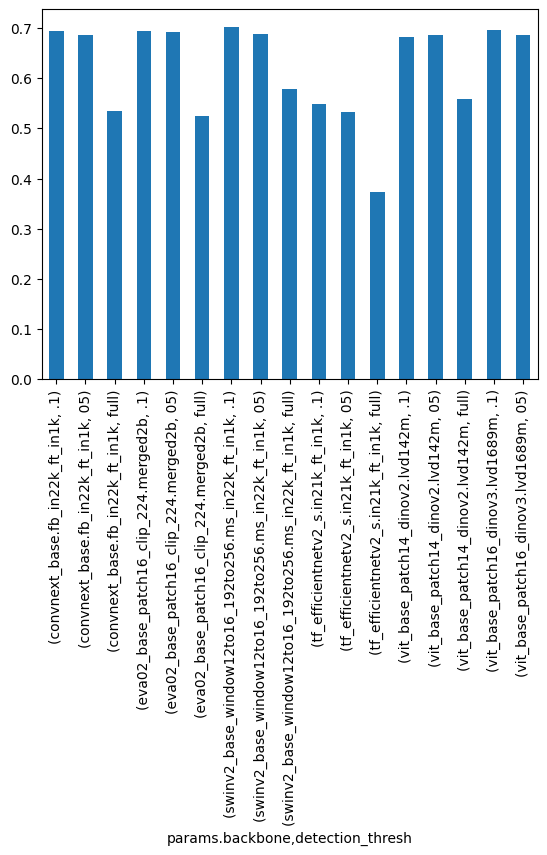

In [32]:
agg_data = df.groupby(['params.backbone', 'detection_thresh'])['metrics.best_val_acc'].mean()
agg_data.plot(kind='bar')

In [33]:
for run_name in df['tags.mlflow.runName'].to_list():
    print(run_name)

vit_so150_fold4
vit_so150_fold3
vit_so150_fold2
vit_so150_fold1
vit_so150_fold0
dino_v3_.1_fold4
dino_v3_.1_fold3
dino_v3_.1_fold2
dino_v3_.1_fold1
dino_v3_.1_fold0
dino_v3_.05_fold4
dino_v3_.05_fold3
dino_v3_.05_fold2
dino_v3_.05_fold1
dino_v3_.05_fold0
mobilenet_fold4
mobilenet_fold3
mobilenet_fold2
mobilenet_fold1
mobilenet_fold0
eva02_.1_b32_fold4
eva02_.1_b32_fold3
eva02_.1_b32_fold2
eva02_.1_b32_fold1
eva02_.1_b32_fold0
convnext_b32_fold4
convnext_b32_fold3
convnext_b32_fold2
convnext_b32_fold1
convnext_b32_fold0
dinov2_vitb14_reg4_fold4
dinov2_vitb14_reg4_fold3
dinov2_vitb14_reg4_fold2
dinov2_vitb14_reg4_fold1
dinov2_vitb14_reg4_fold0
dinov2_.1_192imgsize_fold4
dinov2_.1_192imgsize_fold3
dinov2_.1_192imgsize_fold2
dinov2_.1_192imgsize_fold1
dinov2_.1_192imgsize_fold0
effnetv2s_full_fold4
effnetv2s_full_fold3
effnetv2s_full_fold2
effnetv2s_full_fold1
effnetv2s_full_fold0
effnetv2s_.1_fold4
effnetv2s_.1_fold3
effnetv2s_.1_fold2
effnetv2s_.1_fold1
effnetv2s_.1_fold0
effnetv2s_.05_f

In [34]:
# 3. Reset the index to make index levels into columns
df_plot = agg_data.reset_index()
print("\nDataFrame after reset_index():")
print(df_plot)


DataFrame after reset_index():
                                      params.backbone detection_thresh  \
0                      convnext_base.fb_in22k_ft_in1k               .1   
1                      convnext_base.fb_in22k_ft_in1k               05   
2                      convnext_base.fb_in22k_ft_in1k             full   
3                eva02_base_patch16_clip_224.merged2b               .1   
4                eva02_base_patch16_clip_224.merged2b               05   
5                eva02_base_patch16_clip_224.merged2b             full   
6   swinv2_base_window12to16_192to256.ms_in22k_ft_...               .1   
7   swinv2_base_window12to16_192to256.ms_in22k_ft_...               05   
8   swinv2_base_window12to16_192to256.ms_in22k_ft_...             full   
9                   tf_efficientnetv2_s.in21k_ft_in1k               .1   
10                  tf_efficientnetv2_s.in21k_ft_in1k               05   
11                  tf_efficientnetv2_s.in21k_ft_in1k             full   
12    

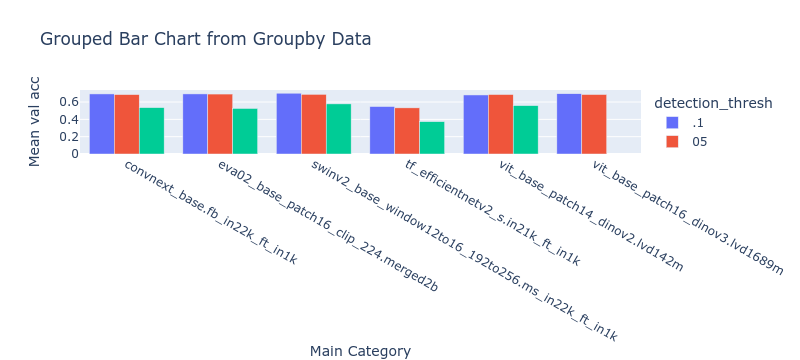

In [35]:


# 4. Plot with Plotly Express
fig = px.bar(
    data_frame=df_plot,
    x="params.backbone",
    y="metrics.best_val_acc",
    color="detection_thresh",
    barmode="group", # Key for grouped bars
    title="Grouped Bar Chart from Groupby Data"
)

# Optional: Further customize the plot
fig.update_layout(xaxis_title="Main Category", yaxis_title="Mean val acc")

# Display the figure
fig.show()


In [36]:
def make_plotly_bars(df, cols):
    for c in cols:
        print(c)
        agg_data = df.groupby(['params.backbone', 'detection_thresh'])[c].mean()
        df_plot = agg_data.reset_index()

        # 4. Plot with Plotly Express
        fig = px.bar(
            data_frame=df_plot,
            x="params.backbone",
            y=c,
            color="detection_thresh",
            barmode="group", # Key for grouped bars
            title=f"Mean for {c}"
        )
    
        # Optional: Further customize the plot
        fig.update_layout(xaxis_title=c, yaxis_title="Mean")
        fig.show()

training_time_m


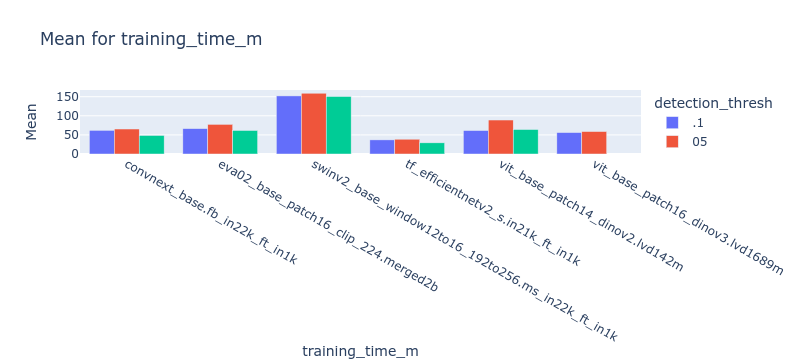

In [37]:
make_plotly_bars(df, ['training_time_m'])

In [38]:
training_time_m

NameError: name 'training_time_m' is not defined

In [ ]:
f1_cols = [c for c in df.columns if 'f1' in c]

In [ ]:
make_plotly_bars(df, f1_cols)

In [ ]:
for c in df.columns:
    if 'f1' in c:
        print(c)

In [ ]:
df['params.augmentation'].value_counts()

In [ ]:
df['params.backbone'].value_counts()

In [ ]:
import plotly.express as px

# 2. Create the bar chart using plotly.express
# Assign the 'LabelText' column to the 'text' parameter for labels on the bars
fig = px.bar(
    runs_df,
    x='tags.mlflow.runName',
    y='metrics.f1_blank',
    # text='LabelText', # Use the 'LabelText' column for the text labels on the bars
    # title="Bar Chart with Custom Labels from a Column"
)

# Optional: Adjust text position and format
# 'text_auto' can be used for automatic text formatting and positioning
# fig = px.bar(df, x='Category', y='Value', text_auto=True, title="Bar Chart with Auto Labels") 
# fig.update_traces(textposition='outside') # Positions labels outside the bars

# 3. Show the figure
fig.show()


In [ ]:
runs_df.columns

In [ ]:
runs_df['tags.mlflow.runName'].unique().tolist()

In [ ]:
runs_df.columns.tolist()

In [ ]:
animal_f1_cols = [x for x in runs_df.columns if 'metrics.f1_' in x]
animal_f1_cols

In [ ]:
animal_labels = [c.split("_")[-1] for c in animal_f1_cols]

In [ ]:
runs_df.shape

In [ ]:
runs_df.head()

In [ ]:
runs_df.columns

In [ ]:
runs_df['tags.mlflow.runName'].to_list()

In [ ]:
# selected_runs = [
#     'convnext_.1',
#      'dinov2_.1',
#     'dino_05_v1',
#     # 'convnext_05_v1', 
#     # 'dinov2_vitb14_0224_1919',
#     'convnext_base_0224_1828',
#     # 'effnetv2s_0224_1503',
#     'dinov2_vits14_v3_0224_1311'
# ]
selected_runs = [x for x in runs_df['tags.mlflow.runName'].to_list() if 'fold' in x]
print(selected_runs)

In [ ]:
selected = runs_df[runs_df['tags.mlflow.runName'].isin(selected_runs)]

In [ ]:
selected

In [ ]:
selected.to_csv(f"{output_dir}/mlflow_data.csv")

In [ ]:
selected["tags.mlflow.runName"].to_list()

In [ ]:
selected['metrics.val_f1_macro']

In [ ]:
import plotly.express as px
import pandas as pd

In [ ]:
runs_df.columns

In [ ]:
f1_metric_cols = [x for x in runs_df.columns if "metrics.f1" in x]

In [ ]:
f1_metric_cols

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

for col in f1_metric_cols:
    print(col)
    runs_df[col].plot(kind='bar')
    plt.show()

    # print(c)
    # col = "metrics.f1_" + c
    
    # fig = px.bar(x=runs_df["tags.mlflow.runName"], y=runs_df[col], title=c)
    # fig.show()
    
    
    
    # fig = make_subplots(
    #     rows=1,
    #     cols=len(select),
    #     subplot_titles=select["tags.mlflow.runName"].tolist(),
    # )
    
    # for idx, (_, row) in enumerate(select.iterrows()):
    #     r = 1
    #     c = idx + 1
        
    #     fig.add_trace(
    #         go.Bar(
    #             x=animal_labels,
    #             y=[row[col] for col in animal_f1_cols],
    #             showlegend=False,
    #         ),
    #         row=r,
    #         col=c,
    #     )
    
    # fig.update_layout(
    #     height=900,
    #     width=1000,
    #     title="F1 per Animal Across Runs",
    # )
    
    # fig.update_yaxes(range=[0, 1])  # recall range
    
    # fig.show()


In [ ]:
runs_df[f1_metric_cols].mean()

In [ ]:
selected[f1_metric_cols].mean()

In [ ]:
for col in f1_metric_cols:
    print(col)
    max_idx = runs_df[col].idxmax()
    model_with_max_score = runs_df.loc[max_idx, "tags.mlflow.runName"]
    print(model_with_max_score)
    print(runs_df.loc[max_idx])
    print('\n')

In [ ]:
runs_df.columns

In [ ]:
from pathlib import Path
import json
import pandas as pd

rows = []
for f in Path("../models").rglob("training_config.json"):
    try:
        cfg = json.loads(f.read_text())
        parts = f.relative_to("../models").parts  # e.g. ('convnext_.1_folds', 'fold_0', 'training_config.json')
        model = parts[0]
        fold = int(parts[1].split("_")[1]) if len(parts) > 2 and "fold" in parts[1] else None
        rows.append({"model": model, "fold": fold, "best_epoch": cfg.get("best_epoch")})
    except (json.JSONDecodeError, KeyError):
        continue

df = pd.DataFrame(rows).sort_values(["model", "fold"]).reset_index(drop=True)
print(df.to_string(index=False))

In [ ]:
df.to_csv('epoch_data.csv')